In [1]:
import statsmodels.api as sm
from statsmodels.compat import lzip
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import OLSInfluence
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = sm.datasets.get_rdataset("Guerry", "HistData").data

In [17]:
model = smf.ols("np.log(Lottery) ~ Literacy + np.log(Pop1831)", data=df).fit()

In [18]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        np.log(Lottery)   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     19.42
Date:                Wed, 13 Aug 2025   Prob (F-statistic):           1.21e-07
Time:                        08:48:32   Log-Likelihood:                -97.920
No. Observations:                  86   AIC:                             201.8
Df Residuals:                      83   BIC:                             209.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          10.6360      1.328      8.006      0.000       7.994      13.278
Literacy           -0.0173      0.005     -3.600      0.001      -0.027      -0.008
np.log(Pop1831)    -1.1017      0.225     -4.889      0.000      -1.550      -0.654
==============================================================================
Omnibus:                       27.021   Durbin-Watson:                   1.857
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               40.491
Skew:                          -1.375   Prob(JB):                     1.61e-09
Kurtosis:                       4.934   Cond. No.                         702.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Linearity

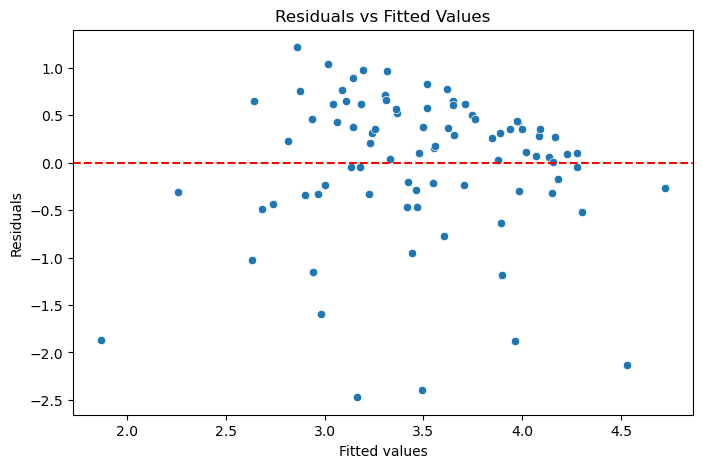

In [19]:
# graphical
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you already have model from statsmodels
fitted_vals = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

In [20]:
# analytical
from statsmodels.stats.diagnostic import linear_rainbow

rainbow_statistic, rainbow_p_value = linear_rainbow(model)
print("Rainbow test p-value:", rainbow_p_value)

Rainbow test p-value: 0.09491985372159042


### No Heteroskedasticity

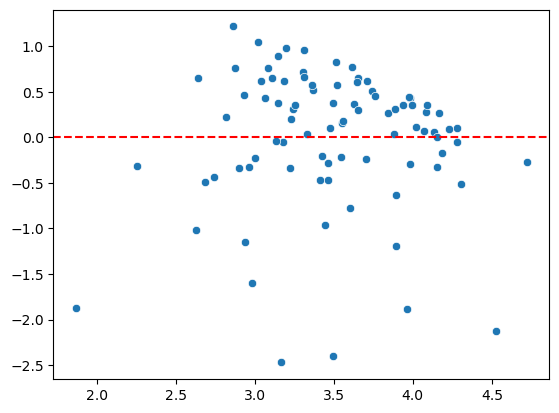

In [21]:
# graphical 
import matplotlib.pyplot as plt
import seaborn as sns

#plt.figure(figsize=(8, 5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(0, color='red', linestyle='--')
# plt.xlabel("Fitted Values")
# plt.ylabel("Residuals")
# plt.title("Residuals vs. Fitted")
# plt.show()

In [22]:
# analytical
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.compat import lzip

bp_test = het_breuschpagan(model.resid, model.model.exog)
bp_labels = ['Lagrange multiplier statistic', 'p-value', 
             'f-value', 'f p-value']
print(lzip(bp_labels, bp_test))

[('Lagrange multiplier statistic', 1.624117386186826), ('p-value', 0.4439431820504456), ('f-value', 0.7988167879113728), ('f p-value', 0.453288727013184)]


### Normality of residuals

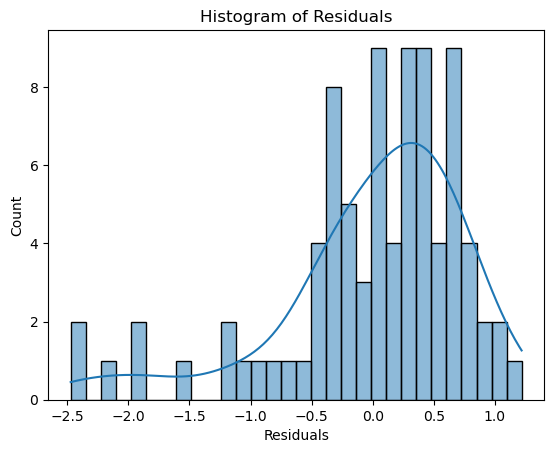

In [24]:
# graphical
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(model.resid, kde=True, bins=30)
plt.xlabel("Residuals")
plt.title("Histogram of Residuals")
plt.show()

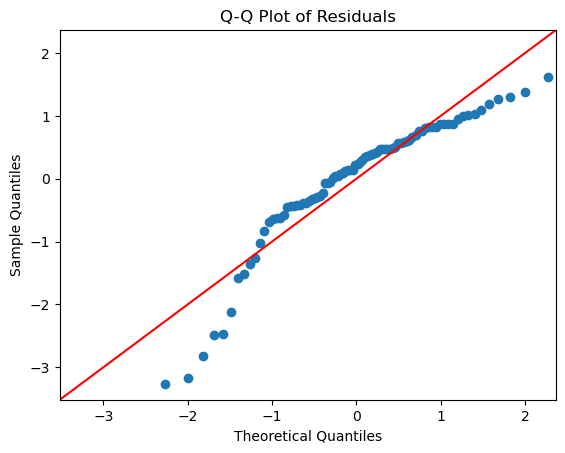

In [25]:
import statsmodels.api as sm

sm.qqplot(model.resid, line='45', fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

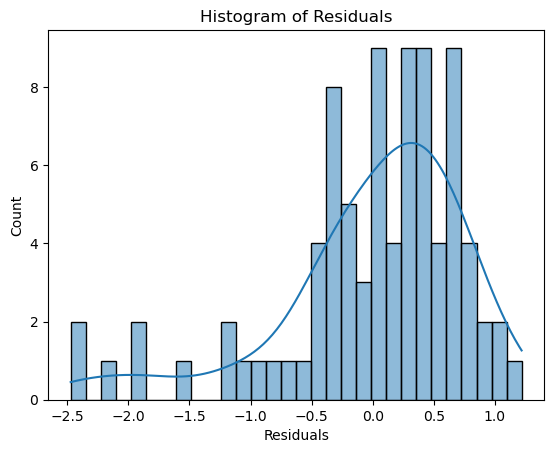

In [ ]:
# analytical


### No autocorrelation

In [ ]:
# graphical


In [ ]:
# analytical


In [10]:
# normality of residuals
## jarque bera test

name = ['Jarque-Bera', 'Chi^2 2-TAIL p-value', 'Skew', 'Kurtosis']
test = sm.stats.jarque_bera(res.resid)

In [11]:
lzip(name, test)

[('Jarque-Bera', 3.3936080248431684),
 ('Chi^2 2-TAIL p-value', 0.1832683123166335),
 ('Skew', -0.48658034311223386),
 ('Kurtosis', 3.003417757881634)]

In [14]:
result = sm.formula.ols('Lottery ~ Literacy + np.log(Pop1831)', data=df).fit()
influence = OLSInfluence(result)